### Exploratory Data Analysis (EDA):

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [233]:
df=pd.read_csv('diabetes.csv')

In [234]:
df.shape

(768, 9)

In [235]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [238]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [239]:
# Check missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [240]:
#checking duplicates
df.duplicated().sum()

0

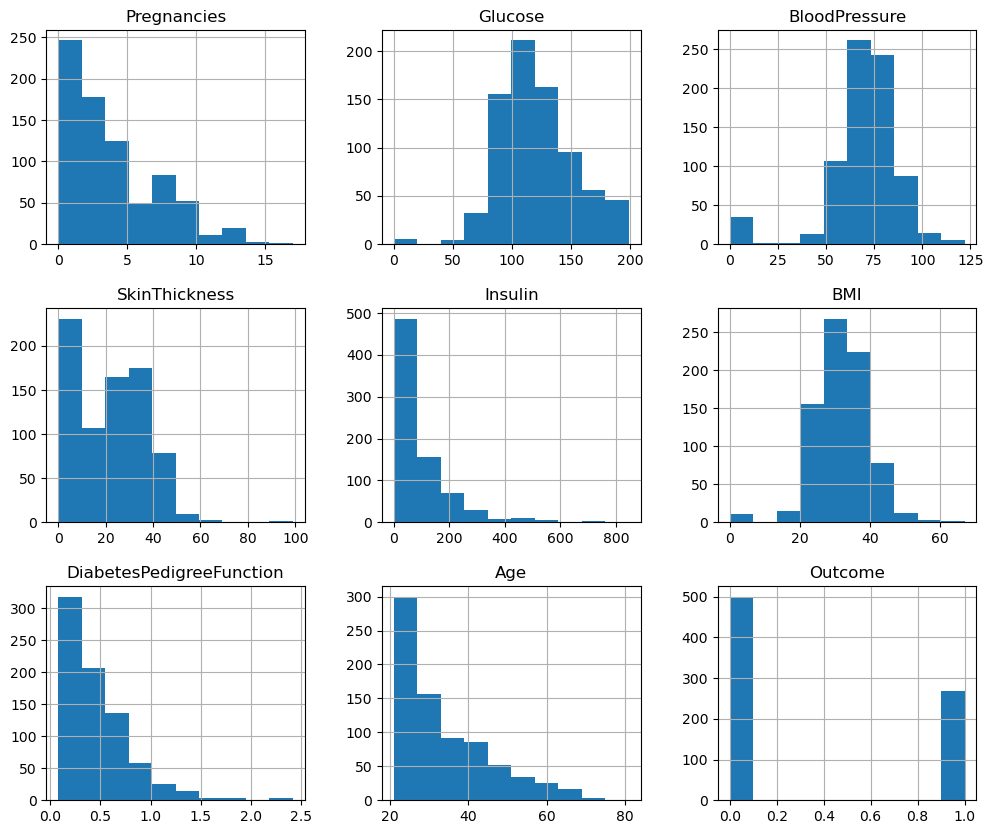

In [241]:
df.hist(figsize=(12,10))
plt.show()

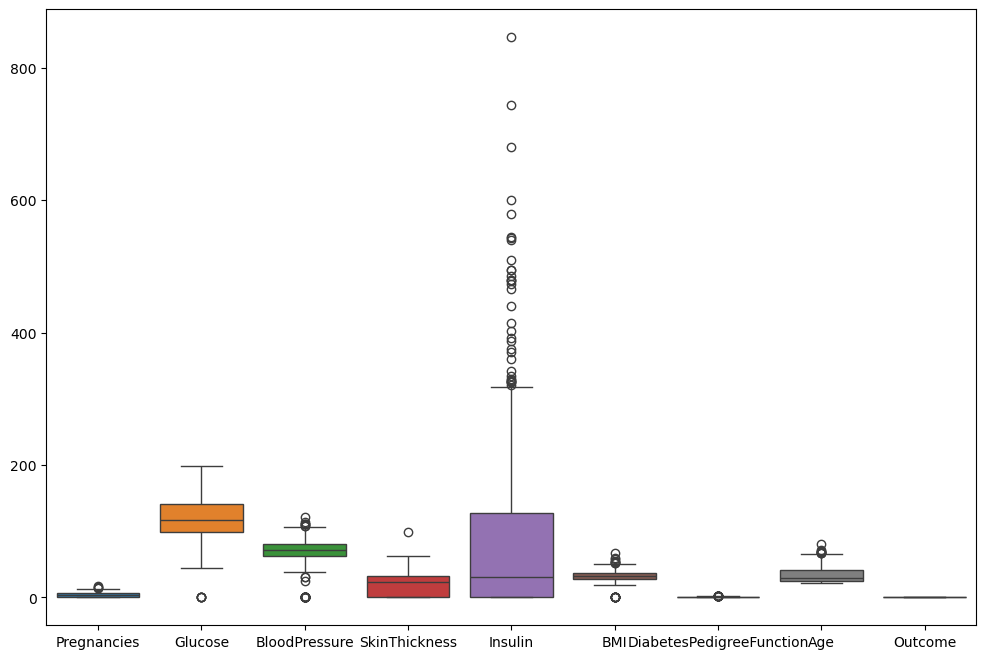

In [242]:
#checking outliers by using boxplot
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

In [243]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

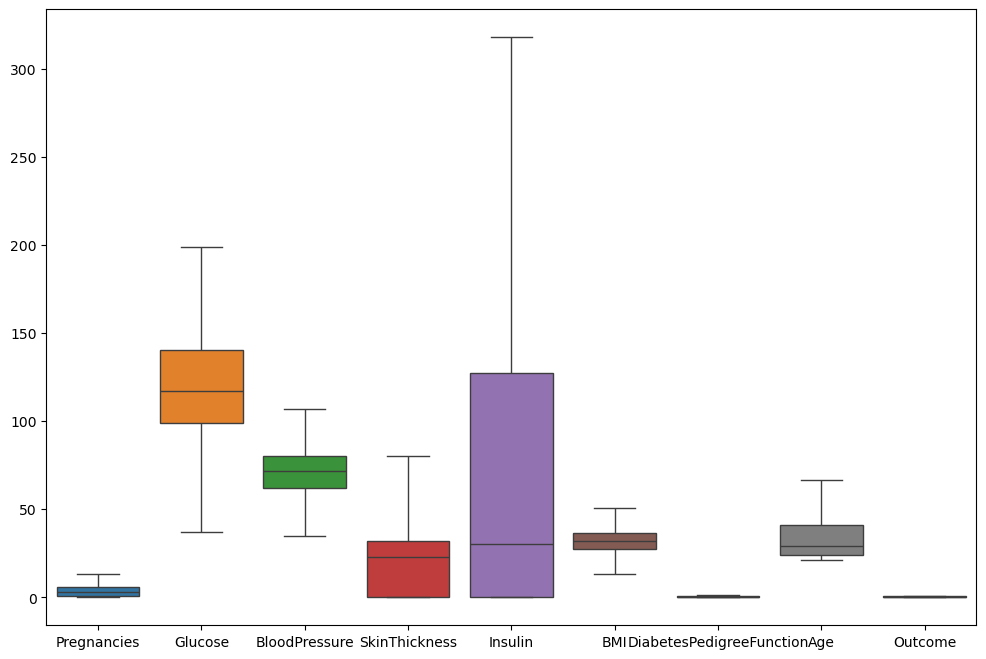

In [244]:
#verifing outliers are present or not
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.show()

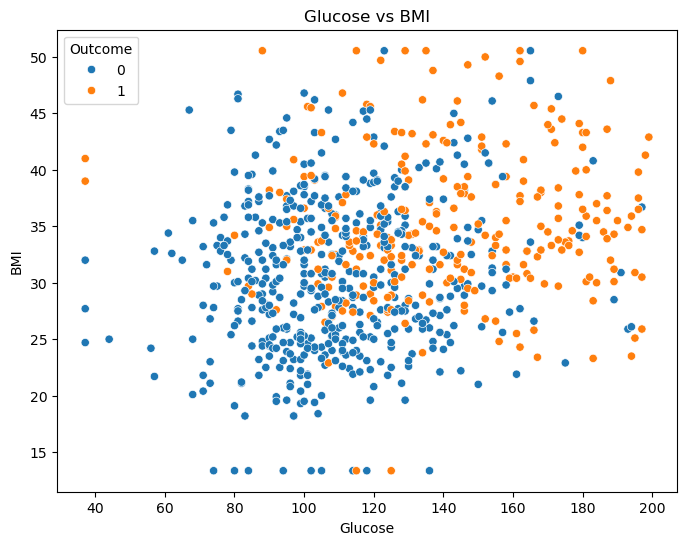

In [245]:
# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Glucose',y='BMI',hue='Outcome',data=df)
plt.title("Glucose vs BMI")
plt.show()

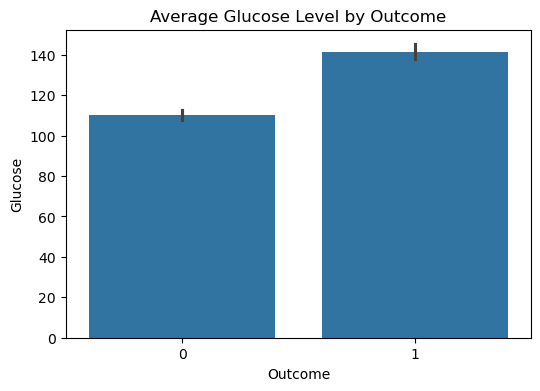

In [247]:
# bar plot
plt.figure(figsize=(6,4))
sns.barplot(x='Outcome',y='Glucose',data=df)
plt.title("Average Glucose Level by Outcome")
plt.show()

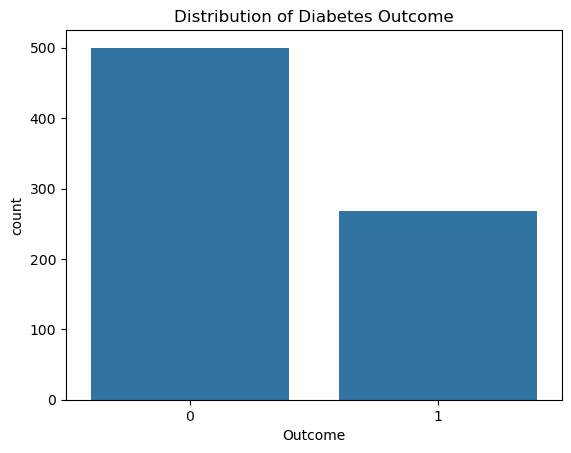

In [185]:
# count plot
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Diabetes Outcome")
plt.show()

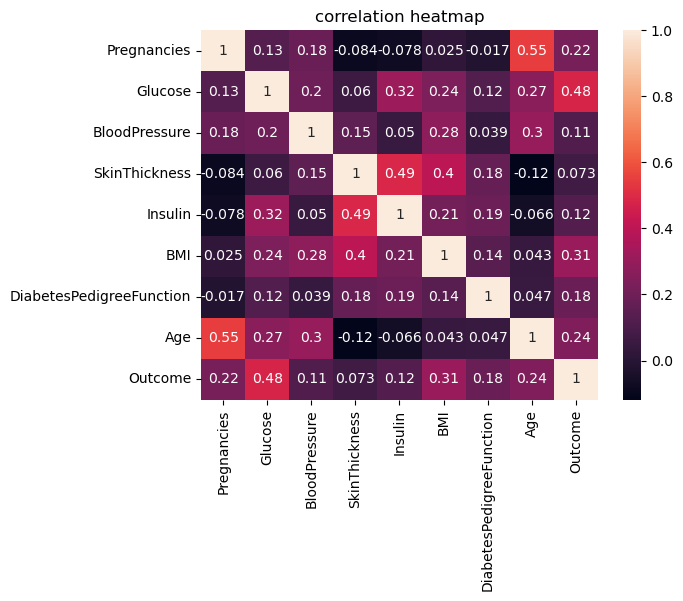

In [248]:
# correlation heatmap
sns.heatmap(df.corr(),annot=True)
plt.title('correlation heatmap')
plt.show()

### Data Preprocessing:

In [249]:
# Check null values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [250]:
# No missing values are present in the dataset.

In [251]:
df.dtypes

Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

In [252]:
# Separate features and target
features= df.drop('Outcome', axis=1)
target= df[['Outcome']]

### Building Predictive Models:

In [253]:
from sklearn.model_selection import train_test_split

In [254]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614, 1)
(154, 1)


In [255]:
! pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [194]:
import lightgbm as lgbm
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [195]:
lgbm_model = lgbm.LGBMClassifier(n_estimators=80,max_depth=2,learning_rate=0.2)

In [196]:
lgbm_model.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 215, number of negative: 399
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350163 -> initscore=-0.618323
[LightGBM] [Info] Start training from score -0.618323
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(learning_rate=0.2, max_depth=2, n_estimators=80)

In [197]:
ypred = lgbm_model.predict(x_test)

In [198]:
accuracy_score(y_test,ypred)

0.7077922077922078

In [199]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       101
           1       0.60      0.45      0.52        53

    accuracy                           0.71       154
   macro avg       0.67      0.65      0.65       154
weighted avg       0.70      0.71      0.70       154



<Axes: >

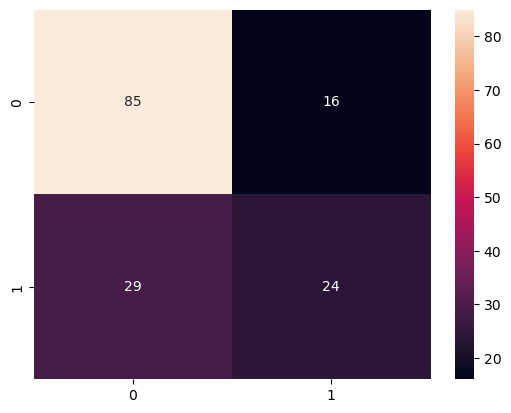

In [200]:
sns.heatmap(confusion_matrix(y_test,ypred),annot=True)

In [201]:
from sklearn.model_selection import GridSearchCV

In [202]:
params = {'learning_rate':[0.2,0.5], 'max_depth':[2,3],'n_estimators':[60,80]}

In [203]:
grid_sea =GridSearchCV(lgbm_model,params,cv=5)

In [204]:
grid_sea.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 172, number of negative: 319
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350305 -> initscore=-0.617697
[LightGBM] [Info] Start training from score -0.617697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

GridSearchCV(cv=5,
             estimator=LGBMClassifier(learning_rate=0.2, max_depth=2,
                                      n_estimators=80),
             param_grid={'learning_rate': [0.2, 0.5], 'max_depth': [2, 3],
                         'n_estimators': [60, 80]})

In [205]:
grid_sea.best_params_,grid_sea.best_score_

({'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 80}, 0.757297081167533)

In [206]:
lgbm_model1 = lgbm.LGBMClassifier(n_estimators=80,max_depth=2,learning_rate=0.2)
lgbm_model1.fit(x_train,y_train)
ypred1 = lgbm_model1.predict(x_test)

[LightGBM] [Info] Number of positive: 215, number of negative: 399
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 657
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.350163 -> initscore=-0.618323
[LightGBM] [Info] Start training from score -0.618323
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [207]:
accuracy_score(y_test,ypred1)

0.7077922077922078

In [208]:
print(classification_report(y_test,ypred1))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       101
           1       0.60      0.45      0.52        53

    accuracy                           0.71       154
   macro avg       0.67      0.65      0.65       154
weighted avg       0.70      0.71      0.70       154



<Axes: >

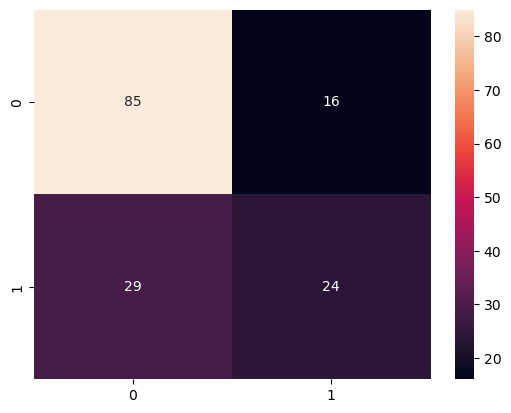

In [209]:
sns.heatmap(confusion_matrix(y_test,ypred1),annot=True)

In [210]:
! pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [211]:
import xgboost as xgb

In [212]:
xgb_model=xgb.XGBClassifier(n_estimators=80,max_depth=2,learning_rate=0.2)

In [213]:
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=80,
              n_jobs=None, num_parallel_tree=None, ...)

In [214]:
ypred2= xgb_model.predict(x_test)

In [215]:
accuracy_score(y_test,ypred2)

0.7207792207792207

In [216]:
print(classification_report(y_test,ypred2))

              precision    recall  f1-score   support

           0       0.76      0.84      0.80       101
           1       0.62      0.49      0.55        53

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154



<Axes: >

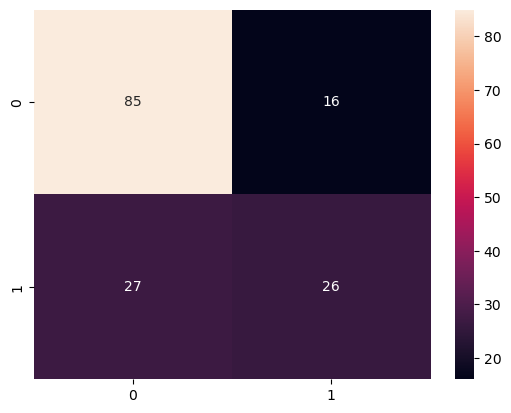

In [217]:
sns.heatmap(confusion_matrix(y_test,ypred2),annot=True)

In [218]:
grid_sea1 = GridSearchCV(xgb_model,params,cv=5)

In [219]:
grid_sea1.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.2, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=2,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=80,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.2, 0.5], 'max_depth': [2, 3],
                         'n_estimators': [60, 80]})

In [220]:
grid_sea1.best_params_

{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 60}

In [221]:
xgb_model2=xgb.XGBClassifier(n_estimators=60,max_depth=2,learning_rate=0.2)

In [222]:
xgb_model2.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=60,
              n_jobs=None, num_parallel_tree=None, ...)

In [223]:
ypred3= xgb_model2.predict(x_test)

In [224]:
accuracy_score(y_test,ypred3)

0.7142857142857143

In [225]:
print(classification_report(y_test,ypred3))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       101
           1       0.60      0.49      0.54        53

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.71       154



<Axes: >

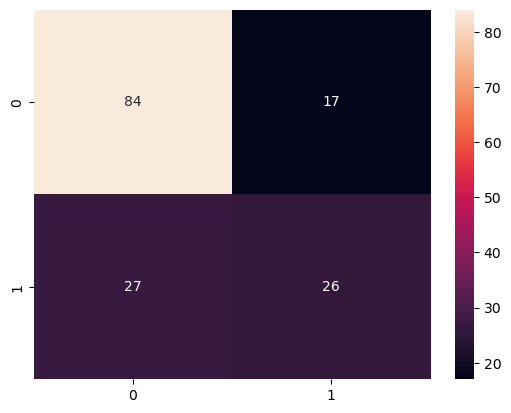

In [227]:
sns.heatmap(confusion_matrix(y_test,ypred3),annot=True)

In [230]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Creating a comparison table
comparison = pd.DataFrame({
    
    'Model': ['LightGBM', 'XGBoost'],
    
    'Accuracy': [
        accuracy_score(y_test, ypred),
        accuracy_score(y_test, ypred2)
    ],
    
    'Precision': [
        precision_score(y_test, ypred),
        precision_score(y_test, ypred2)
    ],
    
    'Recall': [
        recall_score(y_test, ypred),
        recall_score(y_test, ypred2)
    ],
    
    'F1-Score': [
        f1_score(y_test, ypred),
        f1_score(y_test, ypred2)
    ]
})

print(comparison)

      Model  Accuracy  Precision    Recall  F1-Score
0  LightGBM  0.707792   0.600000  0.452830  0.516129
1   XGBoost  0.720779   0.619048  0.490566  0.547368


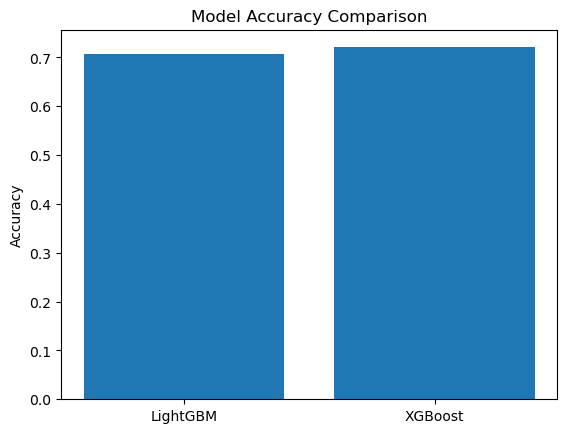

In [231]:
models = ['LightGBM', 'XGBoost']

accuracy = [
    accuracy_score(y_test, ypred),
    accuracy_score(y_test, ypred2)
]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

#### LightGBM

#### XGBoost